# Fetal Health Prediction Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv(r'C:\Users\Bakwowi Junior\Documents\school-documents\4th-semester-SS-26\Machine Learning\ml-evaluation-project\datasets\fetal_health.csv')
df.head()



,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [3]:
# remove rows with missing values
print("Number of rows before dropping missing values:", len(df))
df = df.dropna()
print("Number of rows after dropping missing values:", len(df))


Number of rows before dropping missing values: 2126
Number of rows after dropping missing values: 2126


In [4]:
# Check for missing values
print(df.isnull().sum())

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [5]:
target_col = 'fetal_health'

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)
print(X.shape, y.shape)

(2126, 21) (2126,)


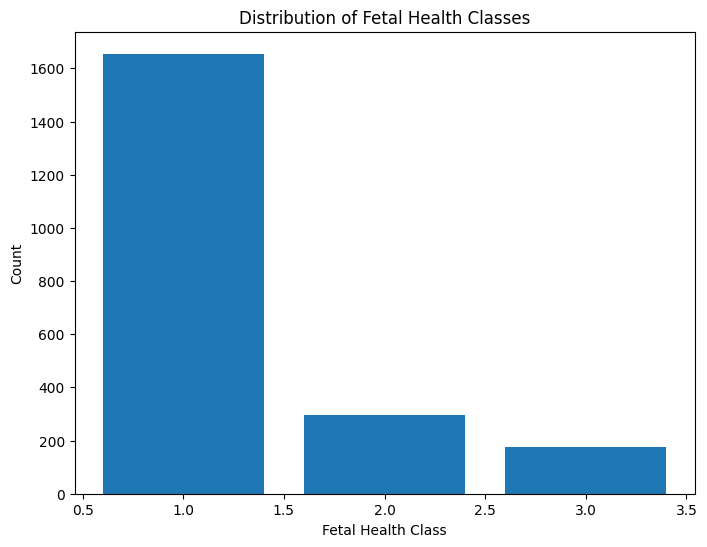

In [6]:
# plot the distribution of the target variable
plt.figure(figsize=(8, 6))
plt.bar(y.value_counts().index, y.value_counts().values)
plt.xlabel('Fetal Health Class')
plt.ylabel('Count')
plt.title('Distribution of Fetal Health Classes')
plt.show()

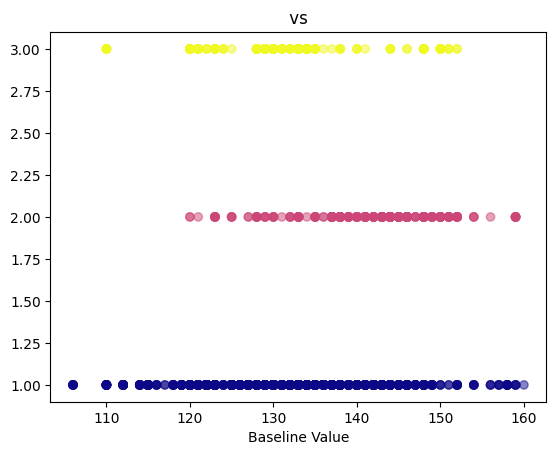

In [15]:
# plotfigure(figsize=(8, 6))
plt.scatter(X['baseline value'], y, c=y, cmap='plasma', alpha=0.5)
plt.xlabel('Baseline Value')
plt.ylabel('')
plt.title(' vs ')
plt.show() #a scatter plot of the target variable against one of the features


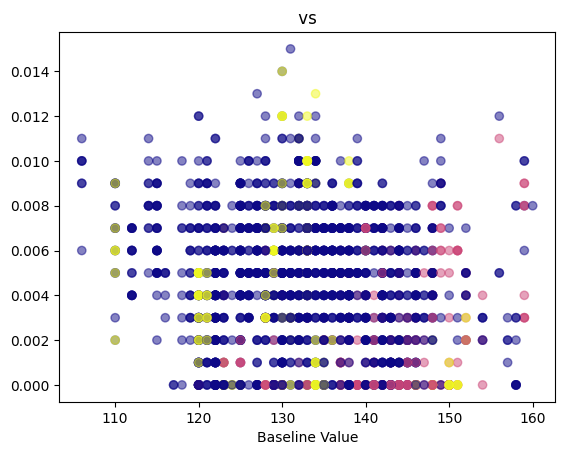

In [17]:
# plotfigure(figsize=(8, 6))
plt.scatter(X['baseline value'], X['uterine_contractions'], c=y, cmap='plasma', alpha=0.5)
plt.xlabel('Baseline Value')
plt.ylabel('')
plt.title(' vs ')
plt.show() #a scatter plot of the target variable against one of the features


In [18]:
print(len(df))
x = df.drop(columns=['fetal_health'])
y = df['fetal_health'].astype(int)
y = y.replace({1: 0, 2: 1, 3: 2})  # Map classes to 0, 1, 2 for better readability
y.value_counts()

2126


fetal_health
0    1655
1     295
2     176
Name: count, dtype: int64

In [ ]:
# plot a correlation heatmap of the features with the target variable
plt.figure(figsize=(12, 10))
sns.heatmap(x.corrwith(y).to_frame(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap of Features with Target Variable')
plt.show()

In [ ]:
# plot a correlation heatmap of the features with each other
plt.figure(figsize=(12, 10))
sns.heatmap(x.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap of Features with Each Other')
plt.show()

In [ ]:
# draw a boxplot of the features with the target variable
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='fetal_health', y='uterine_contractions')
plt.title('Boxplot of Uterine Contractions by Fetal Health Class')
plt.show()

In [38]:
# split data into train and test sets. Strify by target to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20, stratify=y)

In [39]:
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

1700 426
1700 426


In [40]:
# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Original training set class distribution:")
print(y_train.value_counts())
print("Resampled training set class distribution:")
print(y_train_resampled.value_counts())

Original training set class distribution:
fetal_health
0    1323
1     236
2     141
Name: count, dtype: int64
Resampled training set class distribution:
fetal_health
0    1323
1    1323
2    1323
Name: count, dtype: int64


In [18]:
# selector = SelectKBest(
#     score_func=f_classif,
#     k=10
# )
# X_train_selected = selector.fit_transform(
#     X_train_resampled, y_train_resampled
# )

# X_test_selected = selector.transform(X_test)
# selected_features = X_train_resampled.columns[
#     selector.get_support()
# ]

# print(selected_features, len(selected_features))

In [ ]:
knn_for_selection = KNeighborsClassifier(n_neighbors=5)

# ── Pipeline ─────────────────────────────────────────────────────────────────
model = Pipeline([
    ("scaler",   StandardScaler()),
    ("selector", SequentialFeatureSelector(
                     knn_for_selection,
                     n_features_to_select=10,   # starting point; can also grid search this
                     direction="forward",
                     scoring="f1_macro",
                     cv=3                        # inner CV for SFS (keep low for speed)
                 )),
    ("model",    KNeighborsClassifier())         # this one gets tuned
])

# ── Parameter grid ────────────────────────────────────────────────────────────
# Format: "step_name__parameter_name"
param_grid = {
    "selector__n_features_to_select": [5, 10, 15, 20],  # try different subset sizes
    "model__n_neighbors":             [3, 5, 7, 11, 15],
    "model__weights":                 ["uniform", "distance"],
    "model__metric":                  ["euclidean", "manhattan"]
}

# ── Cross-validation strategy ─────────────────────────────────────────────────
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Grid search ───────────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid, 
    cv=cv_outer,
    scoring="f1_macro",
    n_jobs=-1,          # use all CPU cores
    verbose=2,          # print progress
    error_score="raise" # surface errors immediately
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best CV F1:  {grid_search.best_score_:.4f}")
print(f"Best Params: {grid_search.best_params_}")

# ── Evaluate on held-out test set ─────────────────────────────────────────────
y_pred = grid_search.predict(X_test)
print(f"Test F1:     {f1_score(y_test, y_pred, average='macro'):.4f}")

# ── Inspect selected features from best model ─────────────────────────────────
best_pipeline  = grid_search.best_estimator_
best_selector  = best_pipeline.named_steps["selector"]
selected_mask  = best_selector.get_support()
selected_features = X.columns[selected_mask]
print(f"\nSelected features ({selected_mask.sum()}):")
print(selected_features.tolist())

# ── Full results as DataFrame (useful for analysis) ───────────────────────────
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    "param_selector__n_features_to_select",
    "param_model__n_neighbors",
    "param_model__weights",
    "param_model__metric",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

print(results_df.head(10))

In [ ]:
from sklearn.svm import SVC


# ── Fixed SVC inside SFS (cheap, no tuning) ───────────────────────────────────
svc_for_selection = SVC(kernel="rbf", C=1.0, gamma="scale")

# ── Pipeline ──────────────────────────────────────────────────────────────────
model = Pipeline([
    ("scaler",   StandardScaler()),
    ("selector", SequentialFeatureSelector(
                     svc_for_selection,
                     n_features_to_select=10,
                     direction="forward",
                     scoring="f1_macro",
                     cv=3
                 )),
    ("model",    SVC(probability=True))   # this one gets tuned
])

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = [
    # RBF kernel — most powerful, tune C and gamma
    {
        "selector__n_features_to_select": [5, 10, 15, 20],
        "model__kernel": ["rbf", 'linear', 'poly', 'sigmoid'],
        "model__C":      [0.1, 1, 10, 100],
        "model__gamma":  ["scale", "auto", 0.01, 0.1]
    },
    # Linear kernel — good baseline, only tune C
    {
        "selector__n_features_to_select": [5, 10, 15, 20],
        "model__kernel": ["linear"],
        "model__C":      [0.1, 1, 10, 100]
    }
]

# ── Grid search ───────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    error_score="raise"
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best CV F1:  {grid_search.best_score_:.4f}")
print(f"Best Params: {grid_search.best_params_}")

y_pred = grid_search.predict(X_test)
print(f"Test F1:     {f1_score(y_test, y_pred, average='macro'):.4f}")

# ── Selected features ─────────────────────────────────────────────────────────
best_selector = grid_search.best_estimator_.named_steps["selector"]
selected_features = X.columns[best_selector.get_support()]
print(f"\nSelected features: {selected_features.tolist()}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV


# ── Cross-validation strategies ───────────────────────────────────────────────
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # inside RFECV
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # inside GridSearchCV

# ── Pipeline (no scaler needed for RFC) ───────────────────────────────────────
model = Pipeline([
    ("selector", RFECV(
                     estimator=RandomForestClassifier(
                         n_estimators=100,   # fixed inside selector for speed
                         random_state=42
                     ),
                     step=1,                 # remove 1 feature per step
                     cv=cv_inner,
                     scoring="f1_macro",
                     min_features_to_select=5,  # floor — never go below this
                     n_jobs=-1
                 )),
    ("model",    RandomForestClassifier(random_state=42))   # this one gets tuned
])

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    # RFECV params
    "selector__min_features_to_select": [5, 10, 15],  # tune the floor
    "selector__step":                   [1, 2, 3],    # features removed per step

    # RFC params (the final model)
    "model__n_estimators":              [100, 200, 300],
    "model__max_depth":                 [None, 5, 10, 20],
    "model__min_samples_split":         [2, 5, 10],
    "model__max_features":              ["sqrt", "log2"],
    "model__class_weight":              ["balanced", None]
}

# ── Grid search ───────────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_outer,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    error_score="raise"
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best CV F1:  {grid_search.best_score_:.4f}")
print(f"Best Params: {grid_search.best_params_}")

y_pred = grid_search.predict(X_test)
print(f"\nTest F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── Inspect selected features ─────────────────────────────────────────────────
best_pipeline = grid_search.best_estimator_
best_selector = best_pipeline.named_steps["selector"]

selected_mask     = best_selector.get_support()
selected_features = X.columns[selected_mask]
n_selected        = selected_mask.sum()

print(f"\nRFECV selected {n_selected} features (from {X.shape[1]} total):")
print(selected_features.tolist())

# ── Feature importances from final RFC ────────────────────────────────────────
best_rfc = best_pipeline.named_steps["model"]
importance_df = pd.DataFrame({
    "feature":    selected_features,
    "importance": best_rfc.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importances (final model):")
print(importance_df.to_string(index=False))

# ── How many features RFECV chose at each CV fold ─────────────────────────────
print(f"\nRFECV optimal feature count: {best_selector.n_features_}")
print(f"RFECV CV scores across feature counts:\n{best_selector.cv_results_}")

# ── Full grid search results ──────────────────────────────────────────────────
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[[
    "param_selector__min_features_to_select",
    "param_selector__step",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__max_features",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

print("\nTop 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))

In [40]:
# plot the stratified distribution of the target variable in the train and test sets
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sns.countplot(x=y_train.columns[0], data=y_train, ax=axes[0])
# axes[0].set_title('Train Set Distribution')
# sns.countplot(x=y_test.columns[0], data=y_test, ax=axes[1])
# axes[1].set_title('Test Set Distribution')
# plt.show()

Accuracy : 0.9319
Macro Precision : 0.8837
Macro Recall : 0.878
Macro F1 : 0.8798
Weighted F1 : 0.9325

Classification Report:

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       332
     Suspect       0.78      0.85      0.81        59
Pathological       0.91      0.83      0.87        35

    accuracy                           0.93       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426



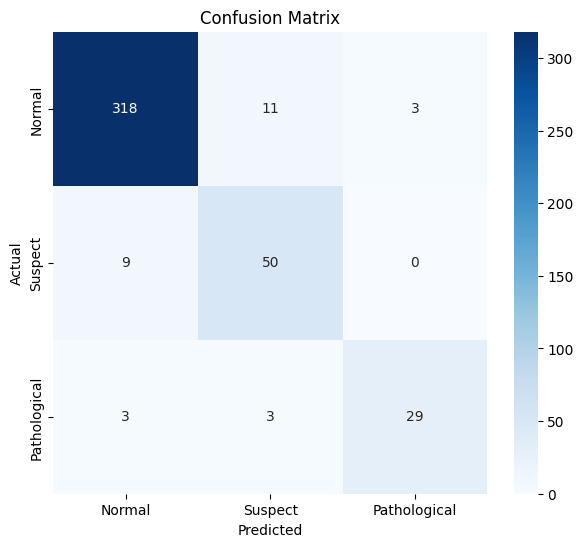

In [43]:

# # fit the pipeline on the training data
# y_pred = model.fit(X_train_resampled, y_train_resampled).predict(X_test)

# # Access the selector step from the pipeline
# sfs_step = model.named_steps["selector"]

# # Now .get_support() works as normal
# selected_mask = sfs_step.get_support()
# selected_features = X.columns[selected_mask]
# print("Selected features:", selected_features.tolist())

# ─────────────────────────────────────────────
# Best Results
# ─────────────────────────────────────────────



# print("Best Parameters:")
# print(model.best_params_)

# print("\nBest CV Macro F1:")
# print(model.best_score_)



accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(
    y_test, y_pred,
    average='macro'
)

recall_macro = recall_score(
    y_test, y_pred,
    average='macro'
)

f1_macro = f1_score(
    y_test, y_pred,
    average='macro'
)

f1_weighted = f1_score(
    y_test, y_pred,
    average='weighted'
)


print("Accuracy :", round(accuracy, 4))
print("Macro Precision :", round(precision_macro, 4))
print("Macro Recall :", round(recall_macro, 4))
print("Macro F1 :", round(f1_macro, 4))
print("Weighted F1 :", round(f1_weighted, 4))


print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
))


cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        "Normal",
        "Suspect",
        "Pathological"
    ],
    yticklabels=[
        "Normal",
        "Suspect",
        "Pathological"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

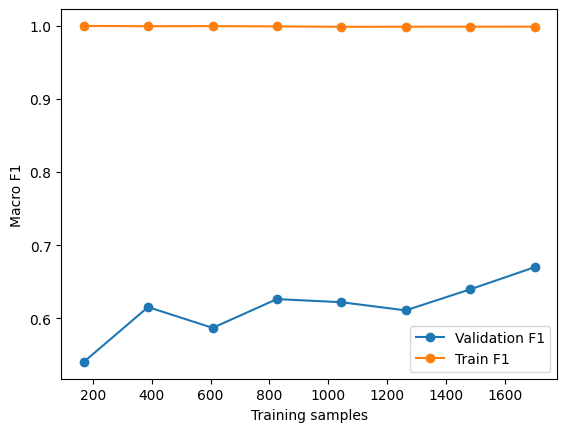

In [46]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    KNeighborsClassifier(11, metric = 'manhattan', weights = 'distance'), 
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation F1")
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train F1")
plt.xlabel("Training samples")
plt.ylabel("Macro F1")
plt.legend()
plt.show()

    